**QuizForge A/B Test Simulation**

**Objective:**

*   Simulate an A/B test using mock user data to practice setting up, running, and interpreting statistical tests.
*   We'll use a control group and a variant group with a slightly different conversion rate, then run a t-test to check for statistical significance.

Loading mock_users Data

In [4]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
mock_users = pd.read_csv('/content/drive/MyDrive/Quiz Forge/mock_users.csv')

mock_users.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,user_id,signup_date,user_persona,subscription_plan,last_login_date,quizzes_created,is_active,signup_month,days_since_signup,days_since_last_login
0,QF1000,2024-03-03,High School Teacher,Free,NaN,7,False,2024-03,181,NaN
1,QF1001,2024-03-03,High School Teacher,Enterprise,2024-08-17,65,True,2024-03,181,14.0
2,QF1002,2024-03-04,Content Creator,Pro,2024-08-13,15,True,2024-03,180,18.0
3,QF1003,2024-03-05,Language Instructor,Free,2024-08-29,8,True,2024-03,179,2.0
4,QF1004,2024-03-06,HR Professional,Free,2024-08-14,2,True,2024-03,178,17.0


In [5]:
import numpy as np

np.random.seed(42)
mock_users['converted'] = np.random.binomial(1, 0.10, size=len(mock_users))

Assign Users to A/B Groups

In [6]:
mock_users['group'] = np.random.choice(['Control', 'Variant'], size=len(mock_users))

mock_users.groupby('group').size()

,0
group,
Control,501
Variant,499


Add Group-Level Effect

In [7]:
variant_mask = mock_users['group'] == 'Variant'

extra_conversions = np.random.binomial(1, 0.02, size=variant_mask.sum())
mock_users.loc[variant_mask, 'converted'] = np.maximum(
    mock_users.loc[variant_mask, 'converted'], extra_conversions
)

Run the A/B Test

In [8]:
from scipy import stats

control_data = mock_users[mock_users['group'] == 'Control']['converted']
variant_data = mock_users[mock_users['group'] == 'Variant']['converted']

t_stat, p_value = stats.ttest_ind(variant_data, control_data, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 1.3306
P-value: 0.183631


Visualization

<Axes: title={'center': 'Control vs Variant Conversion'}, xlabel='group'>

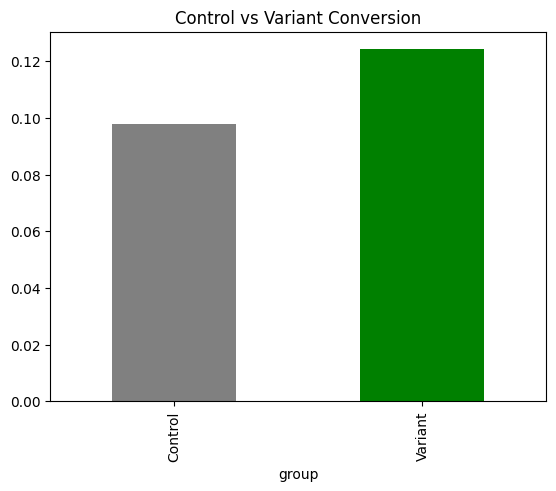

In [9]:
conversion_rates = mock_users.groupby('group')['converted'].mean()
conversion_rates.plot(kind='bar', color=['gray', 'green'], title='Control vs Variant Conversion')